# Trioron perception, step by step — Quantization & the Emitter

*A learning notebook. You invented these concepts (the receptor, the phasor
emitter, the stereo/Vernier unwrap); this walks through how they are actually
implemented in `trioron/core/receptor.py`, one runnable step at a time.*

We build it in five stages:

1. **Quantization** — the receptor: a value → one of 1000 discrete *pockets*, scale-invariant.
2. **The emitter** — the phase code: a pocket → an *angle* on a carrier → a point on the unit circle (a *phasor*).
3. **Lock-in** — reading phases back by summing them; why coherent phases reinforce and spread phases cancel.
4. **The stereo / Vernier emitter** — absolute position as a *relation between two references*, not a value.
5. **Real data** — the same front-end on the 32-class taxonomy, measured against the Bayes ceiling.

Run each cell with `Shift+Enter`. Change the inputs and re-run — the point is to *see* it move.

In [1]:
import sys, math, os
# Run from the repo root so `import trioron` works.
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path: sys.path.insert(0, ROOT)

import torch, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# THE REAL CORE CODE you are learning — not a re-implementation:
from trioron.core.receptor import quantize, phase, quanta_to_phase, N_QUANTA
print("N_QUANTA =", N_QUANTA, " (the number of pockets the receptor partitions into)")

N_QUANTA = 1000  (the number of pockets the receptor partitions into)


## 1. Quantization — the receptor

The receptor self-normalizes **each sample to its own range** and drops every
feature into one of `N_QUANTA = 1000` pockets:

$$\text{lo} = \min(0,\ \min_j x_j),\qquad \text{hi} = \max_j x_j,\qquad
q_j = \mathrm{round}\!\left(1000 \cdot \frac{x_j - \text{lo}}{\text{hi} - \text{lo}}\right)$$

Two design choices worth noticing:
- **lo is floored at 0** (true-zero): a feature of 0 stays "silent", and a *negative* value becomes the new floor.
- **hi is the per-sample peak**: the largest feature saturates to pocket 1000.

*Your optical framing: the receptor adapts its gain to the current stimulus —
like the eye encoding contrast, not absolute luminance.*

In [2]:
x = torch.tensor([0.2, 0.9, 0.5, -0.1])

# Do it by hand first, so the formula is concrete:
lo = torch.minimum(x.min(), torch.tensor(0.0))   # floor at true zero
hi = x.max()
span = hi - lo
q_manual = torch.round(N_QUANTA * (x - lo) / span)
print("x        =", x.tolist())
print("lo, hi   =", lo.item(), hi.item())
print("q_manual =", q_manual.tolist())

# Now the library function — must match:
print("quantize =", quantize(x).tolist())
assert torch.equal(q_manual, quantize(x)), "mismatch!"
print("\nMatches the by-hand computation.")

x        = [0.20000000298023224, 0.8999999761581421, 0.5, -0.10000000149011612]
lo, hi   = -0.10000000149011612 0.8999999761581421
q_manual = [300.0, 1000.0, 600.0, 0.0]
quantize = [300.0, 1000.0, 600.0, 0.0]

Matches the by-hand computation.


### Scale-invariance — the key property

Because every sample divides by its own span, **multiplying the whole input by
any positive constant gives the *identical* quantization.** Absolute magnitude
is thrown away; only the *within-sample pattern* (each feature's ratio to the
peak) survives.

In [3]:
print("quantize(x)      =", quantize(x).tolist())
print("quantize(10 * x) =", quantize(10 * x).tolist())   # identical -> scale-invariant
print("quantize(0.01*x) =", quantize(0.01 * x).tolist()) # identical

# But it is NOT shift-invariant — adding a constant changes the pattern,
# because the true-zero floor moves relative to the values:
print("\nquantize(x + 1)  =", quantize(x + 1).tolist(), " <- shifting DOES change it")

quantize(x)      = [300.0, 1000.0, 600.0, 0.0]
quantize(10 * x) = [300.0, 1000.0, 600.0, 0.0]
quantize(0.01*x) = [300.0, 1000.0, 600.0, 0.0]

quantize(x + 1)  = [632.0, 1000.0, 789.0, 474.0]  <- shifting DOES change it


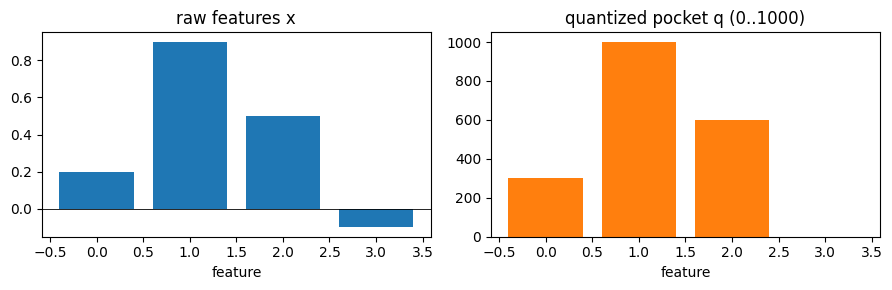

In [4]:
# Visualize: raw feature values vs their quantized pockets
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3))
idx = range(len(x))
a1.bar(idx, x.tolist()); a1.axhline(0, color='k', lw=.6); a1.set_title("raw features x"); a1.set_xlabel("feature")
a2.bar(idx, quantize(x).tolist(), color='C1'); a2.set_title("quantized pocket q (0..1000)"); a2.set_xlabel("feature")
plt.tight_layout(); plt.show()

## 2. The emitter — the phase code

Each pocket becomes an **angle** on a carrier of period `N_QUANTA`:

$$\theta_j = 2\pi \cdot \frac{q_j}{1000} \in [0, 2\pi)$$

and the descriptor is the unit phasor $(\cos\theta_j,\ \sin\theta_j)$ — a point
on the unit circle. *A feature's magnitude has become its angle; "signal ×
radian".* `q=0` sits at angle 0 (silent), `q=1000` wraps a full turn back to 0.

In [5]:
theta = phase(x)                       # = 2*pi*quantize(x)/N_QUANTA
print("q     =", quantize(x).tolist())
print("theta =", [round(t, 3) for t in theta.tolist()], "(radians)")

cos, sin = theta.cos(), theta.sin()    # the [cos, sin] descriptor the lens emits
print("cos   =", [round(c, 3) for c in cos.tolist()])
print("sin   =", [round(s, 3) for s in sin.tolist()])

q     = [300.0, 1000.0, 600.0, 0.0]
theta = [1.885, 6.283, 3.77, 0.0] (radians)
cos   = [-0.309, 1.0, -0.809, 1.0]
sin   = [0.951, 0.0, -0.588, 0.0]


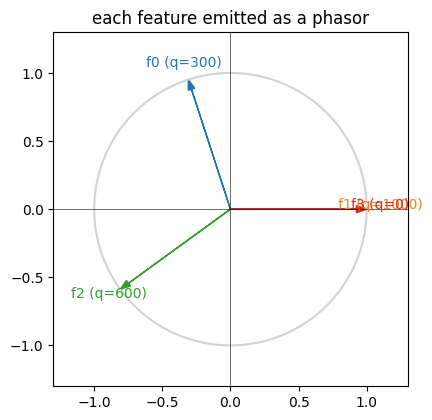

In [6]:
# Each feature as an arrow (phasor) on the unit circle:
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ang = np.linspace(0, 2*np.pi, 200); ax.plot(np.cos(ang), np.sin(ang), color='lightgray')
for j, th in enumerate(theta.tolist()):
    ax.arrow(0, 0, math.cos(th), math.sin(th), head_width=.05, length_includes_head=True, color=f"C{j}")
    ax.text(1.1*math.cos(th), 1.1*math.sin(th), f"f{j} (q={int(quantize(x)[j])})", color=f"C{j}", ha='center')
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')
ax.axhline(0, color='k', lw=.4); ax.axvline(0, color='k', lw=.4)
ax.set_title("each feature emitted as a phasor"); plt.show()

## 3. Lock-in — reading phases back, and the multimodal caveat

To *read* a set of phases you sum the phasors (lock-in):

$$Z = \sum_j e^{i\theta_j}, \qquad |Z| = \text{coherence}.$$

- If the phases **agree** (coherent), the arrows point the same way and add → **large** $|Z|$.
- If the phases are **spread** (incoherent), they cancel → **small** $|Z|$.

This is the heart of the **multimodal weakness** we saw at n=5: a class with
several modes has features whose phases disagree *across* the modes, so a single
mean phasor partially cancels and *underfits*. That's why the honest back-end is
a per-mode mixture (or full-covariance Mahalanobis), not one centroid.

In [7]:
def lock_in(thetas):
    z = np.exp(1j * np.array(thetas)).sum()
    return z, abs(z)

coherent = [0.05, -0.04, 0.10, 0.0]          # phases agree
spread   = [0.0, math.pi/2, math.pi, 3*math.pi/2]  # phases spread around the circle (multimodal)
for name, th in [("coherent", coherent), ("spread (multimodal)", spread)]:
    z, mag = lock_in(th)
    print(f"{name:22s} |Z| = {mag:.3f}   (n={len(th)})")
print("\nCoherent phases reinforce; spread phases cancel -> the multimodal underfit, made literal.")

coherent               |Z| = 3.994   (n=4)
spread (multimodal)    |Z| = 0.000   (n=4)

Coherent phases reinforce; spread phases cancel -> the multimodal underfit, made literal.


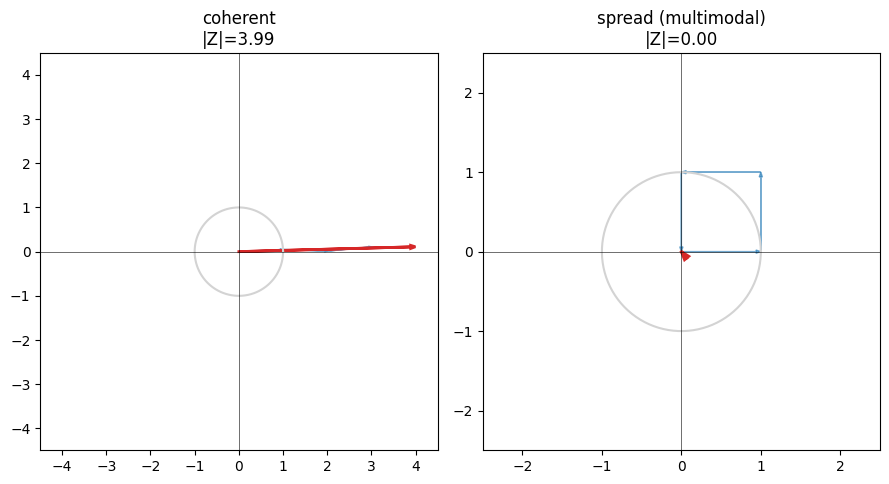

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.6))
for ax, (name, th) in zip(axs, [("coherent", coherent), ("spread (multimodal)", spread)]):
    ang = np.linspace(0, 2*np.pi, 200); ax.plot(np.cos(ang), np.sin(ang), color='lightgray')
    zx = zy = 0.0
    for t in th:
        ax.arrow(zx, zy, math.cos(t), math.sin(t), head_width=.04, length_includes_head=True, color='C0', alpha=.6)
        zx += math.cos(t); zy += math.sin(t)
    ax.arrow(0, 0, zx, zy, head_width=.07, length_includes_head=True, color='C3', lw=2)  # resultant Z
    ax.set_aspect('equal'); ax.set_title(f"{name}\n|Z|={math.hypot(zx,zy):.2f}")
    lim = max(2.5, math.hypot(zx, zy) + .5); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='k', lw=.4); ax.axvline(0, color='k', lw=.4)
plt.tight_layout(); plt.show()

## 4. The stereo / Vernier emitter — position as a *relation*

A single emitter imposes a phase ramp across position: $\theta(p) = 2\pi p / P$.
But phase **wraps** every period $P$, so one emitter reads position only *modulo
P* — a sawtooth, ambiguous (you can't tell $p$ from $p+P$).

Your fix: **two emitters with incommensurate periods** $P_A, P_B$. Each is still
ambiguous alone, but the *pair* $(\phi_A, \phi_B)$ repeats only every
$\mathrm{lcm}(P_A,P_B)$ — unique over the whole field. This is the **Vernier
unwrap**: absolute position recovered from the *relation between two references*,
never from one value.

In [9]:
P_A, P_B = 16.0, 13.0          # incommensurate -> unique over lcm(16,13) = 208
W = 208
p = np.arange(W)
phi_A = (p % P_A) / P_A         # each in [0,1): the wrapped phase of emitter A
phi_B = (p % P_B) / P_B

# Single emitter A is ambiguous: many positions share the same phi_A.
collisions = [int(q) for q in np.where(np.isclose(phi_A, phi_A[5]))[0]]
print(f"positions sharing emitter-A's phase at p=5: {collisions[:8]} ...  <- A alone is ambiguous")

# The PAIR is unique. Recover absolute p from (phi_A, phi_B) by nearest match:
def recover(target_a, target_b):
    da = np.minimum(abs(phi_A - target_a), 1 - abs(phi_A - target_a))  # circular distance
    db = np.minimum(abs(phi_B - target_b), 1 - abs(phi_B - target_b))
    return int((da + db).argmin())

for true_p in [5, 37, 150, 207]:
    rp = recover(phi_A[true_p], phi_B[true_p])
    print(f"true p={true_p:3d}  ->  recovered from (phi_A,phi_B) = {rp:3d}   {'OK' if rp==true_p else 'MISS'}")

positions sharing emitter-A's phase at p=5: [5, 21, 37, 53, 69, 85, 101, 117] ...  <- A alone is ambiguous
true p=  5  ->  recovered from (phi_A,phi_B) =   5   OK
true p= 37  ->  recovered from (phi_A,phi_B) =  37   OK
true p=150  ->  recovered from (phi_A,phi_B) = 150   OK
true p=207  ->  recovered from (phi_A,phi_B) = 207   OK


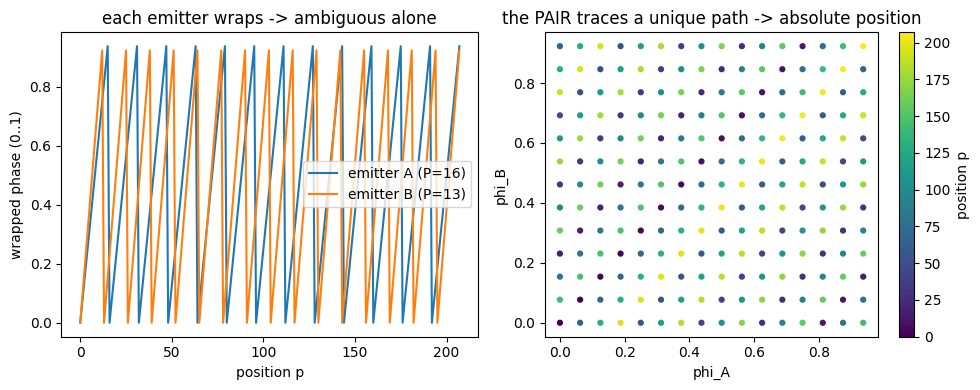

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(p, phi_A, label=f"emitter A (P={P_A:.0f})")
a1.plot(p, phi_B, label=f"emitter B (P={P_B:.0f})")
a1.set_xlabel("position p"); a1.set_ylabel("wrapped phase (0..1)")
a1.set_title("each emitter wraps -> ambiguous alone"); a1.legend()

sc = a2.scatter(phi_A, phi_B, c=p, cmap='viridis', s=12)
a2.set_xlabel("phi_A"); a2.set_ylabel("phi_B")
a2.set_title("the PAIR traces a unique path -> absolute position")
plt.colorbar(sc, ax=a2, label="position p"); plt.tight_layout(); plt.show()

## 5. On real multimodal data — the 32-class taxonomy

Now the front-end on `data_hard`: **K=32 classes, 12 features, 3 modes per
class** (genuinely multimodal), with a Bayes ceiling. We compare **raw features
vs the quantize+emitter phase code**, each read by a **weak** back-end
(nearest-centroid) and a **strong** one (full-covariance Mahalanobis).

Watch for the two findings from the n=5 runs:
- the emitter **helps the weak back-end** (centroid) but is a **substitute, not an
  improvement** on the strong one (Maha ≈ but slightly below raw);
- it only reaches ~93% of Bayes *because* the strong back-end absorbs the
  multimodality the single phasor cancels.

In [11]:
from experiments.progenitor.data_hard import make_split, bayes_accuracy
from experiments.progenitor.taxonomy_manifold import classify_archive
from experiments.progenitor.taxonomy_lens1d import per_feature_q, per_feature_desc, centroid_acc

tr, te = make_split(); K = len(te.names)
print(f"taxonomy: K={K} classes, D={tr.x.shape[1]} features, 3 modes/class")
print(f"chance = {1/K:.3f}   Bayes ceiling = {bayes_accuracy(te):.3f}\n")

# raw standardized features
mu, sd = tr.x.mean(0), tr.x.std(0).clamp_min(1e-6)
raw_tr, raw_te = ((tr.x - mu) / sd).numpy(), ((te.x - mu) / sd).numpy()

# quantize + emitter (per-feature phasor, 24-d)
Qtr, lo, hi = per_feature_q(tr.x); Qte, _, _ = per_feature_q(te.x, lo, hi)
emit_tr, emit_te = per_feature_desc(Qtr), per_feature_desc(Qte)

def maha(Dtr, Dte):
    Tt, Te = torch.from_numpy(Dtr).float(), torch.from_numpy(Dte).float()
    return float((classify_archive(Tt, tr.y, Te, K, full_cov=True) == te.y).float().mean())

print(f"{'representation':<22}{'centroid (weak)':>16}{'Maha (strong)':>16}")
for name, Dtr, Dte in [("raw 12-d", raw_tr, raw_te), ("quantize+emitter 24-d", emit_tr, emit_te)]:
    print(f"{name:<22}{centroid_acc(Dtr, tr.y.numpy(), Dte, te.y.numpy(), K):>16.3f}{maha(Dtr, Dte):>16.3f}")

taxonomy: K=32 classes, D=12 features, 3 modes/class
chance = 0.031   Bayes ceiling = 0.937

representation         centroid (weak)   Maha (strong)


raw 12-d                         0.365           0.901


quantize+emitter 24-d            0.471           0.876


### What you've now seen end to end

- **Quantization** turns a value into a scale-invariant pocket (Section 1).
- **The emitter** turns a pocket into an angle / phasor (Section 2).
- **Lock-in** reads phases by summation, and *spread phases cancel* — the literal
  cause of the multimodal underfit (Section 3).
- **The Vernier emitter** recovers absolute position from the *relation* between
  two incommensurate references — the genuinely novel, working primitive (Section 4).
- On real multimodal data the phase code **learns** and reaches ~93% of Bayes,
  but is a **substitute for, not an improvement over,** raw features on a strong
  back-end (Section 5).

Next notebook (if useful): the 2D **scattering lens** (Gabor → modulus → energy)
that carries image *identity*, and how the Vernier *where*-channel registers a
moving object before the *what*-channel reads it (`combined_what_where`).